# Crude Oil Price Forecasting using Machine Learning and Deep Learning

## Project Overview

This project focuses on forecasting crude oil prices using Machine Learning and Deep Learning techniques. The implementation includes:

* Data preprocessing and cleaning
* Exploratory Data Analysis (EDA)
* Feature Engineering
* Time Series Forecasting
* Random Forest Regressor
* XGBoost Regressor
* LSTM Neural Network
* Model Evaluation
* Visualization of Predictions

### 1. Import Libraries

In [8]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### 2. Load Dataset

In [9]:
# Load dataset
file_path = 'Crude oil.csv'
df = pd.read_csv(file_path)

In [10]:
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,10/28/2022,87.90,241417.0,88.67,88.76,87.08
1,10/27/2022,88.26,273717.0,88.26,89.79,87.33
2,10/26/2022,87.91,271474.0,85.07,88.41,84.14
3,10/25/2022,85.32,226337.0,84.88,86.03,83.06
4,10/24/2022,84.58,238458.0,85.24,85.92,82.63


### 3. Basic Information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2548 entries, 0 to 2547
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2548 non-null   object 
 1   Close/Last  2548 non-null   float64
 2   Volume      2517 non-null   float64
 3   Open        2548 non-null   float64
 4   High        2548 non-null   float64
 5   Low         2548 non-null   float64
dtypes: float64(5), object(1)
memory usage: 119.6+ KB


In [12]:
df.describe()

,Close/Last,Volume,Open,High,Low
count,2548.000000,2.517000e+03,2548.000000,2548.000000,2548.000000
mean,66.043740,3.954717e+05,66.042500,66.959839,65.065043
std,22.732093,2.345385e+05,22.710749,22.820487,22.565127
min,-37.630000,1.530000e+02,-37.250000,-35.200000,-40.320000
25%,48.620000,2.244770e+05,48.665000,49.317500,47.800000
50%,59.720000,3.638160e+05,59.770000,60.545000,58.850000
75%,87.467500,5.581500e+05,87.450000,88.695000,86.342500
max,123.700000,1.693652e+06,124.580000,129.440000,120.790000


In [13]:
df.isnull().sum()

Date           0
Close/Last     0
Volume        31
Open           0
High           0
Low            0
dtype: int64

### 4. Data Cleaning

In [18]:
# Convert Date column
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

# Remove commas and convert numeric columns
for col in ['Open', 'High', 'Low', 'Close/Last']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '')
        df[col] = df[col].astype(float)

# Handle volume column
if 'Volume' in df.columns:
    df['Volume'] = df['Volume'].astype(str).str.replace(',', '')
    df['Volume'] = pd.to_numeric(df['Volume'], errors= 'coerce')

# Fill missing values
df.fillna(method='ffill', inplace=True)

In [19]:
print(df.head())

           Date  Close/Last    Volume   Open   High    Low
2547 2012-10-30       85.68       NaN  85.68  85.68  85.68
2546 2012-10-31       86.24  192354.0  85.73  87.19  85.61
2545 2012-11-01       87.09  185097.0  86.10  87.42  85.92
2544 2012-11-02       84.86  273619.0  86.91  87.24  84.66
2543 2012-11-05       85.65  185846.0  84.65  85.90  84.34


In [16]:
df.isnull().sum()

Date          0
Close/Last    0
Volume        1
Open          0
High          0
Low           0
dtype: int64

### 5. Exploratory Data Analysis (EDA)

#### Oil Price Trend

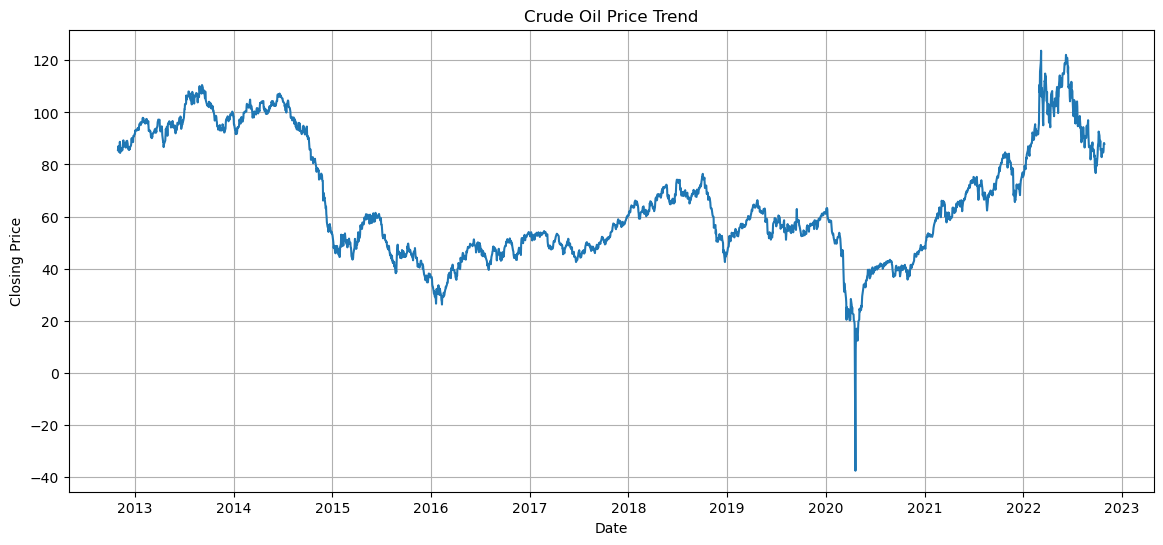

In [20]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Close/Last'])
plt.title('Crude Oil Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

#### Distribution Plot

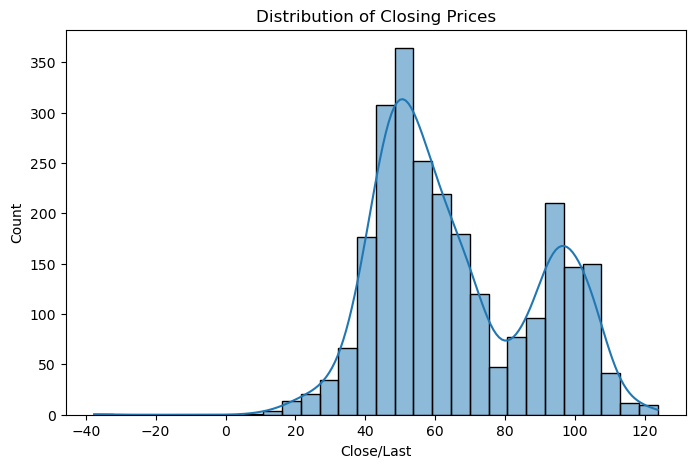

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Close/Last'], bins=30, kde=True)
plt.title('Distribution of Closing Prices')
plt.show()

#### Correlation Heatmap

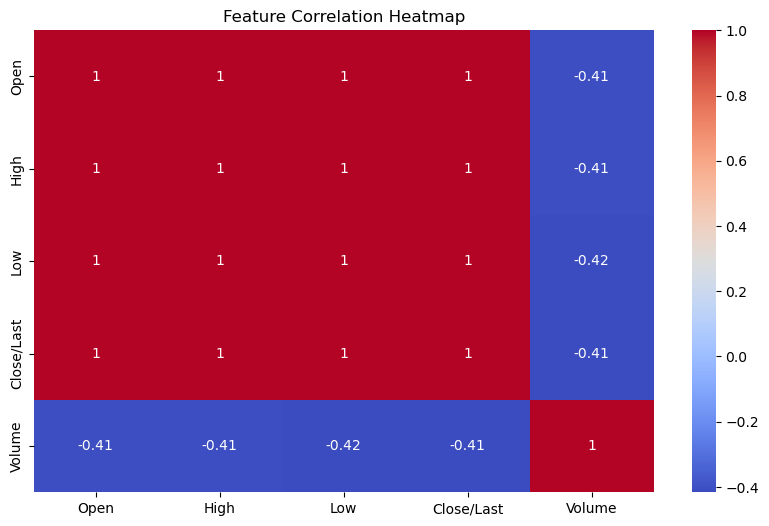

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Open', 'High','Low','Close/Last','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

### 6. Feature Engineering

In [23]:
# Moving averages
df['MA_7'] = df['Close/Last'].rolling(window=7).mean()
df['MA_30'] = df['Close/Last'].rolling(window=30).mean()

# Lag features
df['Lag_1'] = df['Close/Last'].shift(1)
df['Lag_2'] = df['Close/Last'].shift(2)
df['Lag_3'] = df['Close/Last'].shift(3)

# Volatility
df['Volatility'] = df['Close/Last'].rolling(window=7).std()

# Drop null values
df.dropna(inplace=True)

In [24]:
print(df.head())

           Date  Close/Last    Volume   Open   High    Low       MA_7  \
2518 2012-12-10       85.56  180256.0  85.98  86.78  85.33  87.447143   
2517 2012-12-11       85.79  188512.0  85.70  86.37  85.21  87.001429   
2516 2012-12-12       86.77  273858.0  85.69  87.68  85.68  86.670000   
2515 2012-12-13       85.89  196099.0  86.77  86.97  85.81  86.297143   
2514 2012-12-14       86.73  200200.0  86.13  86.92  86.05  86.132857   

          MA_30  Lag_1  Lag_2  Lag_3  Volatility  
2518  86.796667  85.93  86.26  87.88    1.494832  
2517  86.800333  85.56  85.93  86.26    1.450442  
2516  86.818000  85.79  85.56  85.93    1.121398  
2515  86.778000  86.77  85.79  85.56    0.799119  
2514  86.840333  85.89  86.77  85.79    0.469848  


In [25]:
df.isnull().sum()

Date          0
Close/Last    0
Volume        0
Open          0
High          0
Low           0
MA_7          0
MA_30         0
Lag_1         0
Lag_2         0
Lag_3         0
Volatility    0
dtype: int64

### 7. Defines Features and Target

In [26]:
features = ['Open', 'High', 'Low', 'Volume',
            'MA_7', 'MA_30',
            'Lag_1', 'Lag_2', 'Lag_3',
            'Volatility']

X = df[features]
Y = df['Close/Last']

### 8. Train-Test Split

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle = False)

### 9. Random Forest Model

In [28]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, Y_train)

rf_predictions = rf_model.predict(X_test)

#### Random Forest Evaluation

In [30]:
rf_mae = mean_absolute_error(Y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_predictions))
rf_r2 = r2_score(Y_test, rf_predictions)

print('Random Forest Results')
print('MAE: ', rf_mae)
print('RMSE: ', rf_rmse)
print('R2 Score: ', rf_r2)

Random Forest Results
MAE:  1.157470230084694
RMSE:  2.115404792730505
R2 Score:  0.9885451280314916


### 10. XGBoost Model

In [31]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, Y_train)

xgb_predictions = xgb_model.predict(X_test)

#### XGBoost Evaluation

In [33]:
xgb_mae = mean_absolute_error(Y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(Y_test, xgb_predictions))
xgb_r2 = r2_score(Y_test, xgb_predictions)

print('XGBoost Results')
print('MAE: ', xgb_mae)
print('RMSE: ', xgb_rmse)
print('R2 Score: ', xgb_r2)

XGBoost Results
MAE:  1.2342777282472641
RMSE:  2.3142686872763556
R2 Score:  0.9862902091324184


### 11. Prepare Data for LSTM

In [54]:
data = df[['Close/Last']].values

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [57]:
# Create Sequences
sequence_length = 60

X = []
Y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    Y.append(scaled_data[i])

X = np.array(X)
Y = np.array(y)

print(X.shape)
print(Y.shape)

(2459, 60, 1)
(2459, 1)


In [58]:
# Train_Test_Spilt
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

Y_train = Y[:split]
Y_test = Y[split:]

In [59]:
model = Sequential()

model.add(LSTM(
    units=100,
    return_sequences=True,
    input_shape=(X_train.shape[1], 1)
))

model.add(Dropout(0.2))

model.add(LSTM(
    units=100,
    return_sequences=False
))

model.add(Dropout(0.2))

model.add(Dense(50))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 60, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 100)                 │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 126,301 (493.36 KB)

 Trainable params: 126,301 (493.36 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Train Model
history = model.fit(
    X_train,
    Y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0191 - val_loss: 0.0021
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0023 - val_loss: 9.8300e-04
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0019 - val_loss: 8.0023e-04
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - loss: 0.0018 - val_loss: 9.1052e-04
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0015 - val_loss: 7.9854e-04
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0013 - val_loss: 7.1332e-04
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0014 - val_loss: 7.9744e-04
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - loss: 0.0010 - val_loss: 8.1570e-04
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - loss: 0.0011 - val_loss: 7.1817e-04
Epoch 12/50
62/62 ━━━━

In [62]:
# Predictions
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

Y_test_actual = scaler.inverse_transform(Y_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step 


In [63]:
# Evaluation

mae = mean_absolute_error(Y_test_actual, predictions)

rmse = np.sqrt(
    mean_squared_error(Y_test_actual, predictions)
)

r2 = r2_score(Y_test_actual, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.127933186166653
RMSE: 3.99180093711953
R2 Score: 0.9559522551409984


### 12. Compare Models

In [71]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LSTM'],
    'MAE': [rf_mae, xgb_mae, mae],
    'RMSE': [rf_rmse, xgb_rmse, rmse],
    'R2 Score': [rf_r2, xgb_r2, r2]
})

print(results)

           Model       MAE      RMSE  R2 Score
0  Random Forest  1.157470  2.115405  0.988545
1        XGBoost  1.234278  2.314269  0.986290
2           LSTM  3.127933  3.991801  0.955952


### 13. Actual vs Predicted Visualization

#### Random Forest

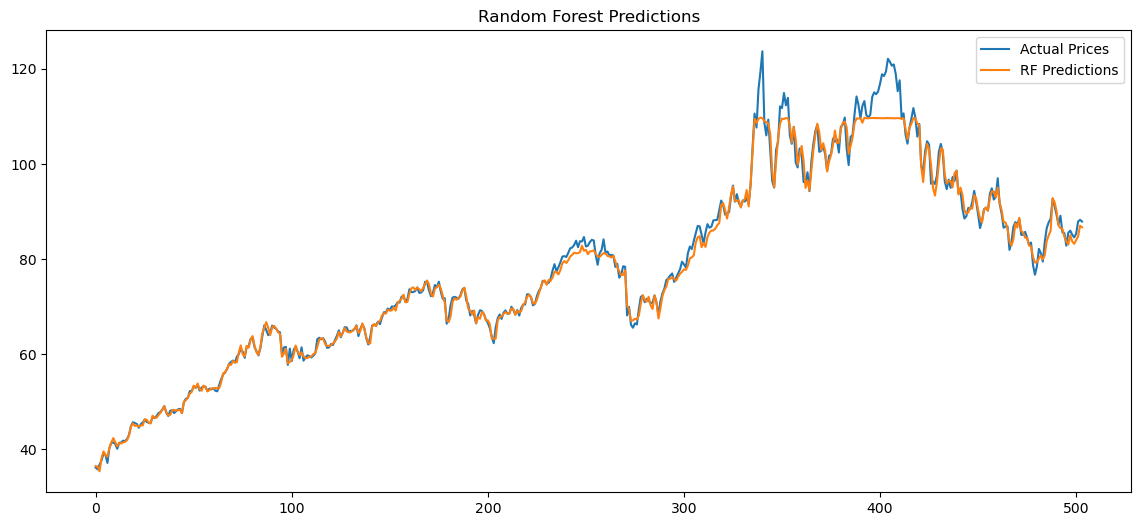

In [49]:
plt.figure(figsize=(14,6))
plt.plot(Y_test.values, label='Actual Prices')
plt.plot(rf_predictions, label='RF Predictions')
plt.title('Random Forest Predictions')
plt.legend()
plt.show()

#### XGBoost

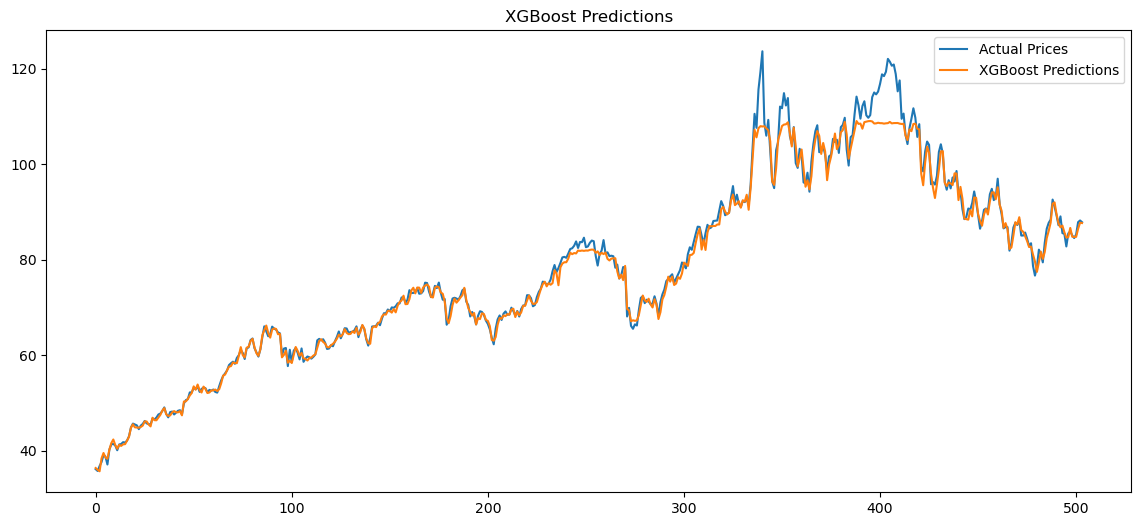

In [50]:
plt.figure(figsize=(14,6))
plt.plot(Y_test.values, label='Actual Prices')
plt.plot(xgb_predictions, label='XGBoost Predictions')
plt.title('XGBoost Predictions')
plt.legend()
plt.show()

#### LSTM

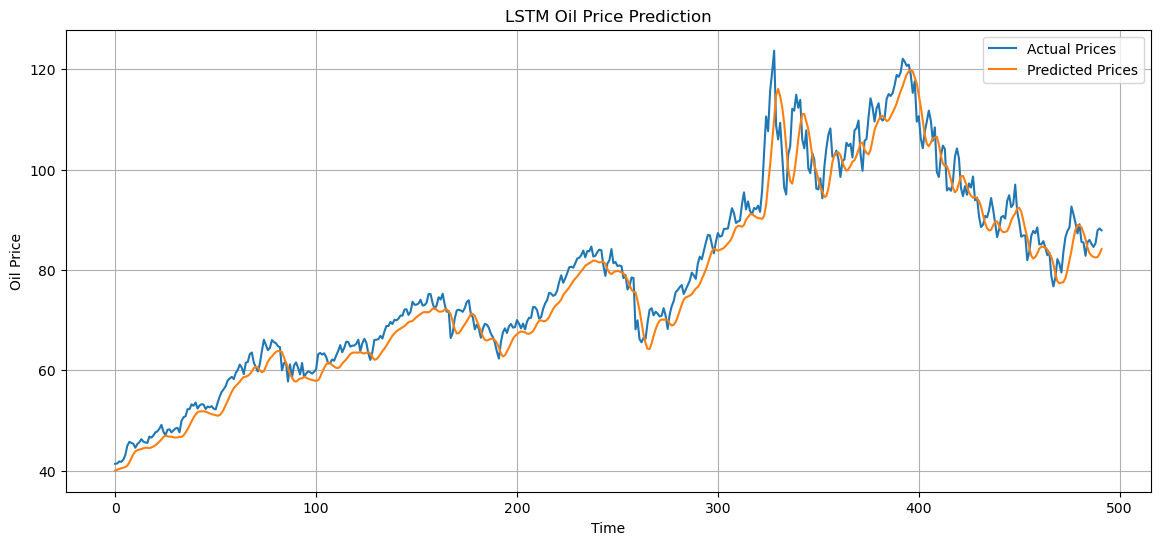

In [68]:
plt.figure(figsize=(14,6))

plt.plot(Y_test_actual, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')

plt.title('LSTM Oil Price Prediction')

plt.xlabel('Time')
plt.ylabel('Oil Price')

plt.legend()
plt.grid(True)

plt.show()

### 14. Feature Importance(Random Forest)

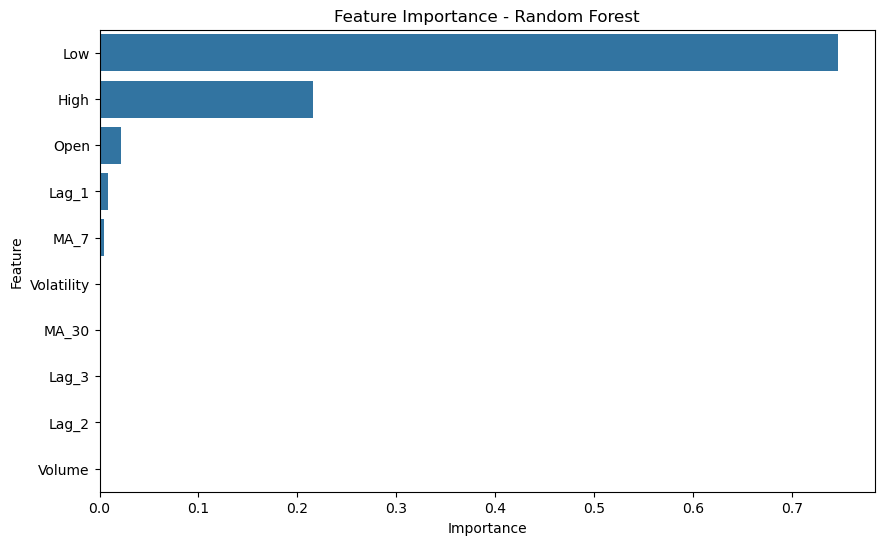

In [69]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance - Random Forest')
plt.show()

### 15. Save Models

In [72]:
import joblib

# Save ML models
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(xgb_model, 'xgboost_model.pkl')

# Save LSTM Model
model.save('lstm_oil_price_model.h5')

print('Models saved successfully!')

Models saved successfully!


In [70]:
print('Business Insights:')
print('- Oil prices show strong volatility patterns over time.')
print('- Lag features and moving averages improve forecasting performance.')
print('- LSTM performs well in capturing sequential time-series patterns.')
print('- XGBoost provides strong predictive performance with engineered features.')
print('- Automated preprocessing pipelines improve scalability and efficiency.')

Business Insights:
- Oil prices show strong volatility patterns over time.
- Lag features and moving averages improve forecasting performance.
- LSTM performs well in capturing sequential time-series patterns.
- XGBoost provides strong predictive performance with engineered features.
- Automated preprocessing pipelines improve scalability and efficiency.
